# Práctica Sesión 3 — Encontrar los spikes

**De la neurona a la figura · Análisis neuronal en insectos asistido por IA**

Un electrodo extracelular casi nunca escucha a **una sola** neurona: escucha a las que tiene cerca.
Las que están más cerca del electrodo producen spikes **más grandes**.

Vas a trabajar con una señal **limpia y simulada** que contiene dos neuronas, y vas a recorrer
el camino completo:

1. Generar la señal y **mirarla** antes de tocarla.
2. Poner un **umbral** y justificarlo.
3. Convertir los cruces de umbral en una **lista de tiempos de spike**.
4. Usar la **amplitud** para separar las dos neuronas.
5. Contar spikes y calcular la **tasa de disparo** de cada una.

Aquí **el código lo escribes tú**. Lo que te damos es la
señal, la especificación de cada función y una forma de comprobar si lo que hiciste funciona.

⏱️ Duración: ~45 minutos, en parejas.

## Cómo funciona este taller

Hay tres tipos de ejercicio. El icono te dice qué te toca hacer:

| | Ejercicio | Qué haces |
|---|---|---|
| ✏️ | **Completa el código** | La celda tiene huecos marcados con `____`. El código **no corre** hasta que los llenes todos. |
| 📋 | **Pega este prompt** | Copia el prompt tal cual en ChatGPT o Claude, lee la respuesta y decide si sirve antes de usarla. |
| ✍️ | **Escribe tu prompt** | Lo redactas tú, con los 5 elementos de abajo. Escríbelo en la celda de texto: hace parte de la entrega. |

Después de los ejercicios numéricos hay una celda de **✅ verificación**: te dice si tu resultado
es correcto, pero no cómo llegar a él.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, seleccionar, cargar, calcular.
3. **Subtipo de tarea.** Line plot, histograma, umbral con `np.where`, período muerto.
4. **Tipo de datos.** *"Un array de numpy `senal` con 40 000 muestras de voltaje en µV, muestreado a 20 000 Hz, donde los spikes son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada línea, que no use librerías extra.

⚠️ Regla del curso: **nunca pegues código que no puedas explicar en voz alta.** En el proyecto
final te vamos a preguntar por tu propio código.

## Antes de empezar: ¿qué es NumPy?

Python por sí solo no maneja bien listas grandes de números — es lento y no permite operar
sobre todos los valores a la vez. **NumPy** es la librería que resuelve eso: introduce el
`array`, un arreglo de números sobre el que puedes operar completo, de un solo golpe.

```python
import numpy as np

x = np.array([1, 2, 3, 4])
x * 2          # -> array([2, 4, 6, 8])   (multiplica cada elemento, sin bucle for)
x + 10         # -> array([11, 12, 13, 14])
```

Funciones que vas a usar hoy:

- `np.arange(inicio, fin, paso)` — números equiespaciados por su *paso*.
- `np.abs(x)` — valor absoluto de cada elemento; `x.max()` / `x.min()` — el mayor y el menor.
- `np.where(condicion)[0]` — los **índices** donde la condición es verdadera.
- `np.argmin(x)` — el índice del valor **mínimo** de `x`.
- `np.diff(x)` — diferencias entre elementos consecutivos; `np.concatenate([a, b])` — pega dos arrays.

**Indexar y recortar (slicing):** el primer elemento es el índice `0`, y `x[a:b]` toma desde
`a` hasta `b` **sin incluir** `b`.

```python
x = np.array([10, 20, 30, 40, 50])
x[0]        # -> 10   (primer elemento)
x[1:3]      # -> array([20, 30])   (índices 1 y 2, no el 3)
x[-1]       # -> 50   (el último)
```

**Máscaras booleanas:** una comparación sobre un array devuelve otro array de `True`/`False`,
y ese array sirve para seleccionar.

```python
x = np.array([10, 20, 30, 40, 50])
x > 25          # -> array([False, False, True, True, True])
x[x > 25]       # -> array([30, 40, 50])
```

Aquí vas a tener un array `t` con los tiempos del registro y un array `senal` con el voltaje en
cada instante. Todas las operaciones se aplican a **todo el array a la vez** — esa es la idea
central de NumPy.

## 0 · Preparación

Ejecuta esta celda primero. Te la damos hecha: define el estilo del curso, la frecuencia de
muestreo y la función `revisar()` que usarás para comprobar tus resultados.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (11, 3.2), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

FS  = 20000          # frecuencia de muestreo (Hz) -> 20 kHz, como en el laboratorio
DUR = 2.0            # duración del registro (segundos)
t   = np.arange(0, DUR, 1/FS)     # vector de tiempos, una entrada por muestra

def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No te dice cómo arreglarla, solo qué falla."""
    if condicion:
        print("  OK   ", nombre)
    else:
        print("  FALLA", nombre, ("  ->  pista: " + pista) if pista else "")

print("Listo. fs =", FS, "Hz  ·  duración =", DUR, "s  ·  muestras =", len(t))

Listo. fs = 20000 Hz  ·  duración = 2.0 s  ·  muestras = 40000


## 1 · La señal

Simulamos un registro extracelular **sin ruido de red y casi sin ruido térmico**: el caso fácil.
Contiene dos neuronas:

| | Distancia al electrodo | Amplitud del spike | Tasa de disparo |
|---|---|---|---|
| **Neurona A** | cerca | ~180 µV | 8 spikes/s |
| **Neurona B** | lejos | ~70 µV | 20 spikes/s |

> ⚠️ La única razón por la que sus amplitudes son distintas es la **distancia al electrodo**.
> No son neuronas con distinto tamaño de potencial de acción.

Esta celda también te la damos hecha. No necesitas entenderla línea por línea hoy; sí necesitas
saber **qué produce**: un array `senal` con el voltaje, y dos listas `tiempos_A` y `tiempos_B`
con los tiempos verdaderos de disparo de cada neurona. Esas dos listas son tu *verdad conocida*:
al final vas a comparar tu detección contra ellas.

In [22]:
rng = np.random.default_rng(7)   # semilla fija -> el "azar" es reproducible

def forma_spike(dur_ms=1.6, fs=FS):
    """Forma bifásica típica de un spike extracelular (bajada rápida, subida lenta)."""
    n = int(dur_ms/1000*fs)                 # duración del spike, en muestras
    x = np.linspace(-1, 1, n)               # eje auxiliar para construir la forma
    w = -np.exp(-((x + 0.15)**2)/0.02) + 0.45*np.exp(-((x - 0.25)**2)/0.06)
    return w / np.abs(w).max()              # normaliza: el pico queda en -1

w = forma_spike()                           # un spike "plantilla"

def poner_spikes(senal, tiempos, amplitud, forma=w):
    """Suma un spike de la amplitud dada en cada tiempo (en segundos)."""
    for ts in tiempos:
        i = int(ts*FS)                      # tiempo (s) -> índice de muestra
        if i + len(forma) < len(senal):     # solo si cabe completo
            senal[i:i+len(forma)] += amplitud * forma   # se suma, no se sobrescribe
    return senal

# Tiempos verdaderos de disparo de cada neurona
tiempos_A = np.sort(rng.uniform(0.02, DUR-0.05, size=int(8*DUR)))    # neurona grande
tiempos_B = np.sort(rng.uniform(0.02, DUR-0.05, size=int(20*DUR)))   # neurona pequeña

senal = rng.normal(0, 3.0, size=len(t))     # ruido térmico mínimo (3 µV)
senal = poner_spikes(senal, tiempos_A, 180) # neurona A: cerca -> spikes grandes
senal = poner_spikes(senal, tiempos_B,  70) # neurona B: lejos -> spikes pequeños

print("Neurona A:", len(tiempos_A), "spikes   |   Neurona B:", len(tiempos_B), "spikes")
print("Total real:", len(tiempos_A) + len(tiempos_B), "spikes en", DUR, "segundos")

Neurona A: 16 spikes   |   Neurona B: 40 spikes
Total real: 56 spikes en 2.0 segundos


---
## 2 · Mirar antes de analizar

**Nunca** analices una señal que no has graficado.

### ✏️ Ejercicio 1 — Completa el código

Escribe una función `ver()` que grafique **solo** la ventana de tiempo que le pidas.
La vas a reutilizar el resto del taller, así que hazla bien.

Fíjate en un detalle: la función **no** llama a `plt.show()`. En Colab la figura se dibuja sola
al final de la celda, y así puedes seguir añadiéndole cosas (una línea de umbral, unos marcadores)
después de llamar a `ver()`.

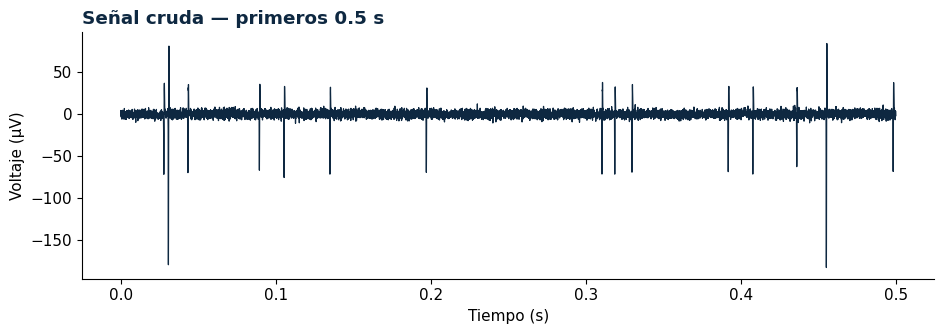

In [23]:
def ver(x, titulo, t0=0.0, t1=0.5, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    m = (t >= t0) & (t < t1)                  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")                    # unidades: segundos
    plt.ylabel("Voltaje (µV)")                   # unidades: microvoltios
ver(senal, "Señal cruda — primeros 0.5 s")

✅ **Revisa tu figura a ojo.** Debe cumplir las cuatro cosas:

- [ ] Se ve **medio segundo** de registro, no los dos segundos completos.
- [ ] El eje horizontal dice *tiempo (s)* y el vertical *voltaje (µV)*.
- [ ] Los picos apuntan **hacia abajo**.
- [ ] Se distinguen picos de **dos tamaños**.

Si alguna falla, arregla la función antes de seguir: todo lo que viene la usa.

**Pregunta 1.** Mirando la figura:

- ¿Hacia dónde apunta el pico de los spikes, arriba o abajo? ¿Por qué crees que es así?
- ¿Cuántos spikes **grandes** cuentas a ojo en esos 0.5 s? ¿Cuadra con los 8 spikes/s de la tabla?

_Escribe tu respuesta aquí:_
Deberia apuntar hacia abajo porque el paso anterior a un potencial de accion es la despolarizacion de la celula, lo que generaria una carga negativa temporal en la zona externa.

Cuento 2 spikes de la primera neurona, lo cual concuerda con la medida de 8 spikes por segundo.

---
## 3 · Poner un umbral

Detectar un spike = decidir **cuándo la señal se aleja demasiado de la línea de base**.

Como el pico de estos spikes es **negativo**, buscamos cruces por debajo de un umbral negativo.
¿Y dónde se pone ese umbral? Necesitas saber **qué tan grande es el ruido**: el umbral tiene que
quedar por fuera del ruido, pero por dentro del spike más pequeño.

La forma más directa de averiguarlo es medir el ruido **donde sabes que no hay spikes**. En este
registro los primeros **20 ms** son línea de base: el primer spike ocurre después. Ahí, lo más
lejos de cero que llega la señal es puro ruido.

> 📌 Existe una forma más fina de cuantificar el ruido — la **desviación estándar** y su versión
> robusta, el **MAD** — pero requiere estadística que todavía no hemos visto. La trabajaremos en la
> **Sesión 4**, cuando el ruido deje de ser despreciable y esta regla sencilla empiece a fallar.

### 📋 Ejercicio 2 — Pega este prompt

Copia este prompt **tal cual** en ChatGPT o Claude. Lee la respuesta completa antes de usarla.

> Trabajo en Python con numpy. Tengo dos arrays de la misma longitud: `t` con tiempos en segundos
> y `senal` con el voltaje en µV de un registro extracelular muestreado a 20000 Hz; los spikes
> aparecen como picos **negativos**. Los primeros 20 ms del registro son línea de base: ahí no hay
> ningún spike. Quiero tres cosas, en tres líneas: (1) seleccionar esa ventana inicial usando `t`;
> (2) medir cuánto se aleja de cero el ruido en esa ventana, en valor absoluto; (3) fijar un umbral
> de detección **negativo**, igual a k veces ese valor, con k = 2. No uses `np.std` ni ninguna
> constante estadística. Explícame por qué conviene medir el ruido en una ventana sin spikes en
> lugar de en todo el registro.

Antes de correr nada, contesta: **¿el código que te dio sirve, o le sobra o le falta algo?**

ruido en la línea de base ≈ 9.8 µV
umbral = -2 × ruido = -19.5 µV


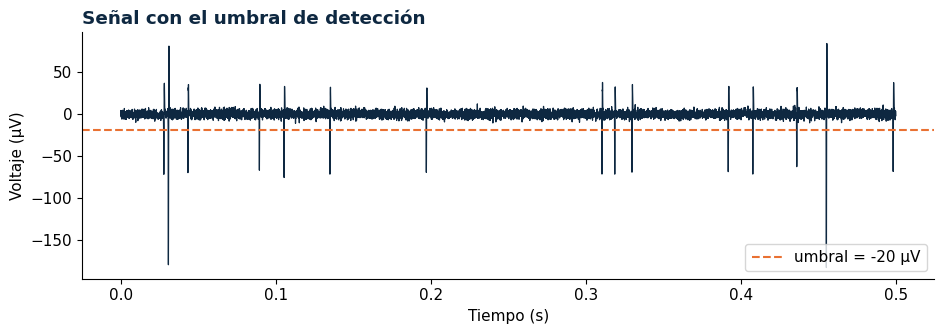

In [24]:
# Escribe aquí el código (el de la IA, corregido por ti, o el tuyo).

# Al final deben quedar definidas estas tres variables:
ventana = senal[t < 0.020]
ruido  = ruido = np.abs(ventana).max()     # lo más lejos de cero que llega el ruido en la línea de base, en µV
k      = 2     # cuántas veces ese ruido exigimos para llamar spike a algo
umbral = -k * ruido     # el umbral de detección, en µV (negativo)

print(f"ruido en la línea de base ≈ {ruido:.1f} µV")
print(f"umbral = -{k} × ruido = {umbral:.1f} µV")

# Grafica la señal con el umbral encima (usa la función que hiciste en el ejercicio 1)
ver(senal, "Señal con el umbral de detección", 0.0, 0.5)
plt.axhline(umbral, color=ORANGE, ls="--", lw=1.5, label=f"umbral = {umbral:.0f} µV")
plt.legend(loc="lower right")

In [25]:
# ✅ VERIFICACIÓN — ejercicio 2
print("Por comparación, el pico más negativo de todo el registro:",
      round(float(senal.min()), 1), "µV\n")

revisar("mediste el ruido en la línea de base, no en todo el registro",
        8 < ruido < 12,
        "si te dio más de 100 µV estás midiendo un spike: la ventana son los primeros 20 ms")
revisar("el umbral es negativo",
        umbral < 0,
        "los spikes de este registro apuntan hacia abajo")
revisar("el umbral es k veces el ruido",
        abs(umbral + k*ruido) < 0.5)
revisar("el umbral queda por fuera del ruido",
        umbral < -12,
        "si el umbral cae dentro del rango del ruido, vas a detectar ruido como si fueran spikes")
revisar("el umbral deja pasar los spikes pequeños (~70 µV)",
        umbral > -60,
        "si el umbral es más negativo que -70 µV, la neurona B no lo cruza nunca")

Por comparación, el pico más negativo de todo el registro: -184.7 µV

  OK    mediste el ruido en la línea de base, no en todo el registro
  OK    el umbral es negativo
  OK    el umbral es k veces el ruido
  OK    el umbral queda por fuera del ruido
  OK    el umbral deja pasar los spikes pequeños (~70 µV)


**Pregunta 2.** Cambia `k` a **0.5** y luego a **8**, y vuelve a ejecutar las dos celdas anteriores.

- Con `k = 0.5`, ¿el umbral corta algo que **no** es un spike? ¿Cómo se llama ese tipo de error?
El umbral corta a la mitad el ruido por lo que seria un falso positivo o error tipo I
- Con `k = 8`, ¿qué neurona desaparece del registro y por qué?
Desapare la nurona B porque su amplitud es menor al umbral de deteccion asignado.
- Entre esos dos extremos hay un rango amplio de valores de `k` que dan **exactamente el mismo
  resultado**. Compruébalo. ¿Por qué esta señal perdona tanto, y en qué situación dejaría de hacerlo?
  Porque hay un vacio entre 4-70 µV en el que el umbral se puede mover libremente. Esto sucede porque solo hay dos señales, muy diferenciadas y limpias. El valor k empezaria a importar si el ruido aumenta, si aparecen más neuronas, si la linea base no es representativa por que tiene picos disparejos.

> Cuando termines, **deja `k` en el valor que elegiste** y vuelve a ejecutar las dos celdas antes de continuar.

---
## 4 · De los cruces a los tiempos de spike

Un problema práctico: un solo spike dura ~1.6 ms y a 20 kHz eso son **32 muestras seguidas**
más negativas que el umbral. Si contaras cada muestra tendrías 32 "spikes" donde hay uno.

La solución: quedarse con el **primer** cruce, buscar el mínimo ahí cerca, y luego ignorar una
ventana corta — un *período muerto* de ~2 ms, inspirado en el período refractario real de la neurona.

### ✍️ Ejercicio 3 — Escribe tu prompt

Esta es la función más difícil del taller, y la vas a pedir tú. Especificación de lo que debe hacer:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `umbral` (número negativo), `muerto_ms=2.0`, `fs=FS` |
| **Salida** | un array de **índices** (no de tiempos), uno por spike detectado |
| **Cómo** | encontrar todos los índices donde `x` está por debajo del umbral; tomar el primero; buscar el **mínimo** dentro de la ventana del período muerto; guardar ese índice; saltar al primer cruce que ocurra después de la ventana y repetir |

Antes de escribir el prompt, repasa los **5 elementos** del principio del taller. Un prompt que
solo diga *"hazme un detector de spikes"* te va a devolver algo que no encaja con estos datos.

_Escribe aquí el prompt que le vas a dar a la IA:_

>Trabajo en Python con NumPy y tengo dos arrays de la misma longitud: `t`, con tiempos en segundos, y `senal`, con voltaje en µV de un registro extracelular muestreado a `20000 Hz`. Necesito una función con la interfaz `def detectar_spikes(x, umbral, muerto_ms=2.0, fs=FS):` que reciba `x` como array 1D de voltaje, `umbral` como número negativo, `muerto_ms` como período muerto en milisegundos y `fs` como frecuencia de muestreo, y que detecte spikes mediante el siguiente algoritmo: encontrar todos los índices donde `x[i] < umbral`, tomar el primer índice candidato, definir desde ese índice una ventana correspondiente al período muerto (`muerto_ms * fs / 1000`, redondeando de forma explícita a un número entero de muestras), buscar dentro de esa ventana el valor mínimo de `x` y guardar el índice donde ocurre como el spike detectado; después, saltar hasta el final de esa ventana, ignorar todos los cruces de umbral que ocurran dentro de ella y buscar el primer cruce posterior para repetir el procedimiento hasta llegar al final de la señal. La función debe devolver únicamente un array de NumPy con los índices de los spikes detectados, no los tiempos ni los valores de voltaje. Debe manejar correctamente una ventana incompleta al final del registro, validar que `x` sea 1D y que `fs > 0`, usar únicamente NumPy, priorizar un código eficiente pero fácil de entender y **documentar detalladamente cada parte del código y explicar paso a paso su funcionamiento**.

**¿Qué líneas del código no entiendes?** Pregúntale a la IA en la misma conversación:
*"¿Qué hace esta línea de código: (pega la línea)?"*

>

_¿Qué le tuviste que corregir a la respuesta?_

>

In [26]:
def detectar(x, umbral, muerto_ms=2.0, fs=FS):
    # tu código aquí
    """
    Detecta índices de spikes en una señal de voltaje mediante cruce de umbral,
    aplicando un período muerto para no contar el mismo evento más de una vez.

    Parámetros
    ----------
    x : np.ndarray, 1D
        Voltaje de la señal, en µV.
    umbral : float
        Umbral de detección, negativo (los spikes son deflexiones negativas).
    muerto_ms : float
        Período muerto después de cada detección, en milisegundos.
    fs : float
        Frecuencia de muestreo, en Hz.

    Devuelve
    -------
    np.ndarray de enteros
        Índices (posiciones en x) donde ocurre cada spike detectado,
        ordenados de menor a mayor. No devuelve tiempos ni voltajes.
    """

    # --- 1. Validaciones de entrada -----------------------------------------
    x = np.asarray(x)                       # por si llega una lista en vez de un array
    if x.ndim != 1:
        raise ValueError("x debe ser un array 1D")
    if fs <= 0:
        raise ValueError("fs debe ser mayor que 0")

    n = len(x)

    # --- 2. Período muerto, convertido de milisegundos a número de muestras -
    # muerto_ms/1000 -> segundos; segundos * fs (muestras/segundo) -> muestras.
    # round() es explícito a propósito: int() por sí solo trunca (29.9 -> 29),
    # mientras que round() redondea al entero más cercano (29.9 -> 30).
    muerto_muestras = int(round(muerto_ms * fs / 1000))
    muerto_muestras = max(muerto_muestras, 1)   # como mínimo, una ventana de 1 muestra

    # --- 3. Todos los índices donde la señal cruza el umbral -----------------
    # np.where devuelve, en orden, cada posición donde x[i] < umbral.
    # No son "spikes" todavía: son solo candidatos, muchas veces varios por spike
    # (mientras la señal se mantiene por debajo del umbral, varias muestras seguidas
    # cumplen la condición).
    candidatos = np.where(x < umbral)[0]

    if len(candidatos) == 0:
        return np.array([], dtype=int)          # no hay ningún cruce: no hay nada que detectar

    # --- 4. Recorrer los candidatos, saltando de evento en evento ------------
    spikes = []          # aquí se van guardando los índices de spike ya confirmados
    pos = 0               # puntero: posición dentro del array 'candidatos'

    while pos < len(candidatos):
        inicio = candidatos[pos]                 # primer candidato que todavía no fue procesado

        # Ventana del período muerto: desde 'inicio' hasta 'inicio + muerto_muestras'.
        # min(..., n) recorta la ventana si se sale del array -> maneja el caso
        # de una ventana incompleta al final del registro.
        fin = min(inicio + muerto_muestras, n)

        # Dentro de esa ventana, el spike es el punto más negativo (el pico real
        # del potencial de acción), no el primer cruce -- por eso se busca el mínimo.
        ventana = x[inicio:fin]
        offset = np.argmin(ventana)              # posición del mínimo, relativa al inicio de la ventana
        indice_spike = inicio + offset           # posición absoluta en x
        spikes.append(indice_spike)

        # Saltar hasta el final de la ventana: cualquier candidato con índice < fin
        # queda ignorado, porque cae dentro del período muerto que ya se procesó.
        # np.searchsorted busca, en 'candidatos' (que ya está ordenado de menor a mayor
        # porque así lo entrega np.where), la primera posición cuyo valor es >= fin.
        # Esa posición es exactamente "el primer cruce posterior" que pide el enunciado.
        pos = np.searchsorted(candidatos, fin, side="left")

    return np.array(spikes, dtype=int)


idx        = detectar(senal, umbral)   # índices de muestra
tiempos    = t[idx]                    # índices -> tiempos, en segundos
amplitudes = senal[idx]                # voltaje del pico de cada spike, en µV

print("spikes detectados:", len(idx))
print("Primeros 5 tiempos (s):", np.round(tiempos[:5], 4))

spikes detectados: 55
Primeros 5 tiempos (s): [0.0278 0.0308 0.0434 0.0895 0.1054]


In [27]:
# ✅ VERIFICACIÓN — ejercicio 3
idx = np.asarray(idx)

revisar("detectar() devuelve índices enteros, no tiempos",
        idx.dtype.kind in "iu" and idx.max() < len(senal),
        "los índices son posiciones en el array; los tiempos salen después, con t[idx]")
revisar("el número de spikes detectados es plausible (entre 50 y 60)",
        50 <= len(idx) <= 60,
        "si te salen cientos, no estás aplicando el período muerto; si te salen ~16, tu umbral es muy exigente")
revisar("cada índice cae por debajo del umbral",
        bool(np.all(senal[idx] < umbral)),
        "estás guardando el índice del cruce o de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(tiempos) >= 0.0019)),
        "después de detectar un spike tienes que saltar 2 ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(idx) > 0)))

  OK    detectar() devuelve índices enteros, no tiempos
  OK    el número de spikes detectados es plausible (entre 50 y 60)
  OK    cada índice cae por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


📋 **Y ahora pega este prompt**, con tu propia función:

> Este código detecta spikes negativos con un umbral y un período muerto de 2 ms:
> [pega aquí tu función `detectar`]
> Explícame qué pasaría si dos neuronas dispararan con menos de 2 ms de diferencia.
> ¿Qué error cometería el detector y cómo se llama ese problema en electrofisiología?

_Resume en una frase lo que aprendiste de la respuesta:_

Como el valor que se toma por spike es el valor minimo que toca el umbral, la función solo leeria la neurona con la mayor amplitud. Por otro lado, debido a la forma en que se construyo la función,  cuando dos spikes salen al mismo tiempo la grafica los suma, por lo que se puede desplazar el tiempo real de la primera medida.

En este caso se cometeria un error de tipo II, un falso negativo o un solapamiento de spikes. Cualquier segundo evento que caiga dentro de la ventana de un evento anterior queda invisible para el algoritmo.

>

---
## 5 · Separar las dos neuronas

Ya tenemos **todos** los spikes mezclados. Para saber cuál es de cuál usamos lo único que las
distingue: la **amplitud del pico**.

Si el histograma de amplitudes tiene **dos montones separados**, podemos cortar en el valle.

### ✏️ Ejercicio 4 — Completa el código

Text(0.0, 1.0, 'Histograma de amplitudes: ¿cuántos grupos ves?')

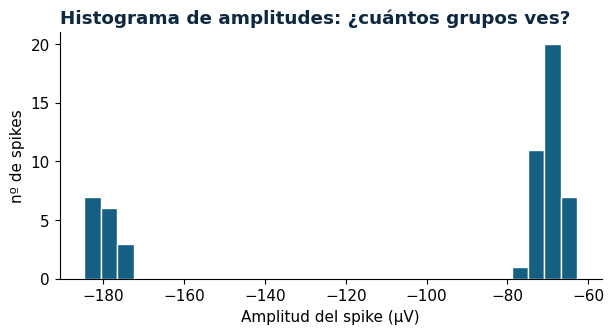

In [28]:
plt.figure(figsize=(7, 3.2))
plt.hist(amplitudes, bins=30, color=TEAL, edgecolor="white")   # ¿qué variable contiene las amplitudes?
plt.xlabel("Amplitud del spike (µV)")                                       # con unidades
plt.ylabel("nº de spikes")
plt.title("Histograma de amplitudes: ¿cuántos grupos ves?",
          color=NAVY, fontweight="bold", loc="left")

In [29]:
corte = -120          # µV — léelo del valle del histograma de arriba

es_A = amplitudes < corte     # ¿< o >? los spikes de A son los MÁS negativos
es_B = ~es_A                     # ~ invierte la máscara: todo lo que no es A

tiempos_A_det = tiempos[es_A]
tiempos_B_det = tiempos[es_B]

print(f"Neurona A (grande):  {len(tiempos_A_det)} spikes")
print(f"Neurona B (pequeña): {len(tiempos_B_det)} spikes")

Neurona A (grande):  16 spikes
Neurona B (pequeña): 39 spikes


In [30]:
# ✅ VERIFICACIÓN — ejercicio 4
revisar("el corte cae entre los dos montones del histograma",
        float(amplitudes.min()) < corte < float(amplitudes.max()),
        "míralo otra vez en el histograma: tiene que caer en el valle, no en un extremo")
revisar("cada spike quedó asignado a una sola neurona",
        len(tiempos_A_det) + len(tiempos_B_det) == len(tiempos))
revisar("el grupo A tiene tantos spikes como los que generamos",
        len(tiempos_A_det) == len(tiempos_A),
        "si te da al revés, revisa el signo de la comparación: A es la MÁS negativa")
revisar("el grupo A es en promedio más grande que el B",
        amplitudes[es_A].mean() < amplitudes[es_B].mean())

  OK    el corte cae entre los dos montones del histograma
  OK    cada spike quedó asignado a una sola neurona
  OK    el grupo A tiene tantos spikes como los que generamos
  OK    el grupo A es en promedio más grande que el B


**Pregunta 3.** ¿Qué pasaría si las dos neuronas estuvieran a distancias **parecidas** del
electrodo?

- Describe cómo se vería el histograma de amplitudes en ese caso.

Se veria una sola montaña con dos picos o una más ancha pero no habria un valle para poner como corte
- Explica por qué el método de arriba fallaría.

Si se solapan las dos distribuciones no se podría usar la amplitud como un elemento decisivo. En ese caso habrian falsos positivos de A (spikes de B que, por casualidad, salieron grandes y quedaron del lado equivocado del corte), y
falsos negativos de A (spikes de A que salieron chicos y se clasificaron como B).
- ¿Qué otra característica del spike (además de la amplitud) podrías usar para separarlas?

La forma completa del spike, no solo el punto minimo, ancho del spike, relación entre el pico de bajada y el de subida, pendiente de bajada del voltaje.


### ✍️ Ejercicio 5 — Escribe tu prompt

Ahora quieres **una figura que demuestre que la separación funcionó**: los primeros 0.5 s de la
señal, en gris, con un marcador triangular sobre el pico de cada spike — naranja para la neurona A,
azul para la neurona B — y una leyenda.

Redáctalo tú. Acuérdate de decirle qué variables tienes ya (`t`, `senal`, `tiempos_A_det`,
`tiempos_B_det`, `amplitudes`, `es_A`, `es_B`) y qué colores usa el curso.

_Escribe aquí tu prompt:_

Trabajo en Python con NumPy. Tengo las siguientes variables: `t`, con tiempos en segundos; `senal`, con voltaje en µV de un registro extracelular muestreado a 20000 Hz; `tiempos_A_det`, con los tiempos de disparo detectados de la neurona A; `tiempos_B_det`, con los tiempos de disparo detectados de la neurona B; `amplitudes`, con la amplitud de cada spike; `es_A`, con las amplitudes clasificadas como pertenecientes a la neurona A (lado izquierdo del punto de corte del histograma); y `es_B`, con las amplitudes clasificadas como pertenecientes a la neurona B (lado derecho del histograma). Necesito una gráfica que permita comprobar visualmente que la separación de las dos neuronas por amplitud funcionó correctamente: debe mostrar únicamente los primeros 0.5 segundos de `senal` en color gris y colocar un marcador triangular exactamente sobre el pico de cada spike detectado, usando **naranja para la neurona A** y **azul para la neurona B**, además de incluir una **leyenda clara** que identifique la señal y cada neurona. La gráfica debe usar los tiempos de `tiempos_A_det` y `tiempos_B_det` para ubicar los spikes y obtener de `senal` el voltaje correspondiente a cada pico, limitar correctamente el eje x a 0–0.5 s, tener etiquetas de ejes y un formato limpio y fácil de interpretar. Usa únicamente NumPy y Matplotlib y documenta claramente el código.
>

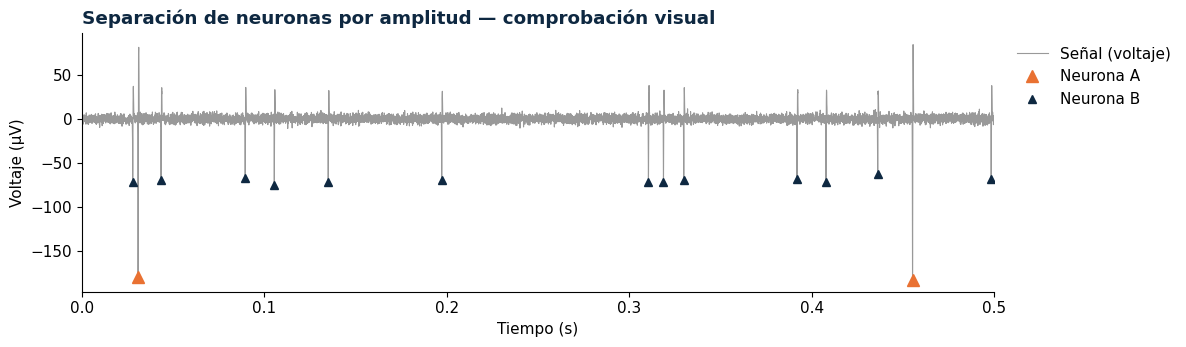

In [31]:
# Pega aquí el código de tu figura y ajústalo hasta que se vea bien.
# --- Ventana de tiempo a mostrar ------------------------------------------
t0, t1 = 0.0, 0.5                                  # los primeros 0.5 s del registro

# --- Filtrar los tiempos de spike que caen dentro de esa ventana ---------
# Se hace ANTES de graficar: si le pasas a plt.plot() tiempos fuera del
# rango que vas a mostrar, matplotlib igual los "cuenta" para la escala
# del eje y la figura queda comprimida o con huecos raros.
mA = (tiempos_A_det >= t0) & (tiempos_A_det < t1)
mB = (tiempos_B_det >= t0) & (tiempos_B_det < t1)

tA_ventana = tiempos_A_det[mA]                     # tiempos de A, solo en la ventana
tB_ventana = tiempos_B_det[mB]                     # tiempos de B, solo en la ventana

# --- Tiempo -> índice, para leer el voltaje real del pico en 'senal' -----
# Los tiempos están en segundos; senal está indexada por muestra.
# round() antes de convertir a int: redondea al índice más cercano,
# en vez de truncar (que sesgaría siempre hacia la muestra anterior).
idx_A = np.round(tA_ventana * FS).astype(int)
idx_B = np.round(tB_ventana * FS).astype(int)

vA = senal[idx_A]                                  # voltaje (µV) en el pico de cada spike de A
vB = senal[idx_B]                                  # voltaje (µV) en el pico de cada spike de B

# --- Recortar también la señal cruda a la misma ventana -------------------
mt = (t >= t0) & (t < t1)

# --- Figura -----------------------------------------------------------------
plt.figure(figsize=(12, 3.6))

# la señal cruda, de fondo, en gris para que no compita visualmente
# con los marcadores de color
plt.plot(t[mt], senal[mt], color="0.6", lw=0.8, label="Señal (voltaje)")

# un marcador triangular ("^", apuntando hacia abajo, como el propio spike)
# sobre el pico de cada spike detectado, coloreado según la neurona
plt.plot(tA_ventana, vA, "^", color=ORANGE, ms=8, ls="none",
         label="Neurona A ")
plt.plot(tB_ventana, vB, "^", color=NAVY, ms=6, ls="none",
         label="Neurona B ")

# --- Formato ------------------------------------------------------------
plt.xlim(t0, t1)                                    # fija el eje x a la ventana pedida
plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (µV)")
plt.title("Separación de neuronas por amplitud — comprobación visual",
          color=NAVY, fontweight="bold", loc="left")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()

✅ **Revisa tu figura a ojo:**

- [ ] Los triángulos caen **encima** de los picos, no flotando en el aire ni desplazados.
- [ ] Todos los picos grandes son de un color y todos los pequeños del otro.
- [ ] Hay leyenda, y los ejes tienen unidades.

---
## 6 · La tasa de disparo

$$\text{tasa de disparo (Hz)} = \frac{\text{número de spikes}}{\text{duración del registro (s)}}$$

Es la medida más básica de actividad neuronal y la vas a usar todo el semestre.

### ✏️ Ejercicio 6 — Completa el código

Neurona A: 8.0 spikes/s
Neurona B: 19.5 spikes/s


Text(0.0, 1.0, 'Tasa de disparo')

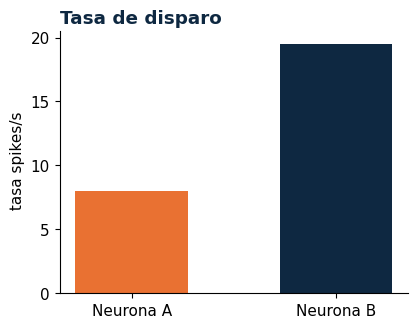

In [32]:
tasa_A = len(tiempos_A_det) / (t[-1] - t[0])
tasa_B = len(tiempos_B_det) / (t[-1] - t[0])

print(f"Neurona A: {tasa_A:.1f} spikes/s")
print(f"Neurona B: {tasa_B:.1f} spikes/s")

plt.figure(figsize=(4.5, 3.4))
plt.bar(["Neurona A", "Neurona B"], [tasa_A, tasa_B], color=[ORANGE, NAVY], width=0.55)
plt.ylabel(" tasa spikes/s")                     # con unidades
plt.title("Tasa de disparo", color=NAVY, fontweight="bold", loc="left")

In [33]:
# ✅ VERIFICACIÓN — ejercicio 6
revisar("tasa_A son spikes por segundo, no un conteo",
        abs(tasa_A - len(tiempos_A_det)/DUR) < 0.01,
        "dividiste por el número equivocado: la duración del registro está en DUR")
revisar("tasa_B son spikes por segundo, no un conteo",
        abs(tasa_B - len(tiempos_B_det)/DUR) < 0.01)
revisar("la neurona B dispara más rápido que la A",
        tasa_B > tasa_A,
        "ojo: B es la pequeña en amplitud, pero la rápida en tasa")

  OK    tasa_A son spikes por segundo, no un conteo
  OK    tasa_B son spikes por segundo, no un conteo
  OK    la neurona B dispara más rápido que la A


---
## 7 · ¿Le acertamos?

La ventaja de trabajar con datos simulados: **conocemos la respuesta correcta**. Comparemos lo
detectado con los tiempos que generamos en el paso 1.

### ✏️ Ejercicio 7 — Completa el código

In [34]:
print(f"{'':12} {'real':>8} {'detectado':>12}")
print(f"{'Neurona A':12} {len(tiempos_A):8} {len(tiempos_A_det):12}")
print(f"{'Neurona B':12} {len(tiempos_B):8} {len(tiempos_B_det):12}")

# ¿Cuán lejos quedó cada tiempo detectado del tiempo real más cercano? (en ms)
err = [np.min(np.abs(tiempos_A - ts))*1000 for ts in tiempos_A_det]
print(f"\nError temporal mediano en la neurona A: {np.median(err):.2f} ms")

                 real    detectado
Neurona A          16           16
Neurona B          40           39

Error temporal mediano en la neurona A: 0.63 ms


Ese error mediano **no es cero**, y no es un fallo: `poner_spikes` coloca el *inicio* del spike
en el tiempo verdadero, mientras que `detectar` devuelve el instante del **mínimo**, que llega
un poco después. Es un desfase sistemático, no ruido.

Falta **un** spike de la neurona B. ¿Dónde se perdió? Hay dos sospechosos:

1. Un spike que quedó justo por **encima** del umbral y no lo cruzó.
2. Dos spikes que cayeron dentro del mismo **período muerto** y se contaron como uno.

Completa la celda siguiente para revisar el segundo sospechoso.

In [35]:
todas_reales = np.sort(np.concatenate([tiempos_A, tiempos_B])) #tiempos_A y timepos_B están en segundos
isi = np.diff(todas_reales) * 1000          # intervalos entre spikes consecutivos, en MILISEGUNDOS

colisiones = np.where(isi < 2)[0]        # ¿cuál es el período muerto de tu detector, en ms?
print("Pares de spikes separados por menos del período muerto:", len(colisiones))
for i in colisiones:
    print(f"  t = {todas_reales[i]:.4f} s  y  {todas_reales[i+1]:.4f} s"
          f"  ->  {isi[i]:.2f} ms de diferencia")

Pares de spikes separados por menos del período muerto: 1
  t = 1.0122 s  y  1.0137 s  ->  1.49 ms de diferencia


In [36]:
# ✅ VERIFICACIÓN — ejercicio 7
revisar("isi está en milisegundos",
        1 < float(np.median(isi)) < 200,
        "si la mediana te da ~0.03, todavía está en segundos")
revisar("encontraste al menos una colisión",
        len(colisiones) >= 1,
        "compara contra el período muerto que usaste en detectar(), en ms")
revisar("el total detectado y el total real se diferencian en pocos spikes",
        abs(len(tiempos) - (len(tiempos_A) + len(tiempos_B))) <= 3)

  OK    isi está en milisegundos
  OK    encontraste al menos una colisión
  OK    el total detectado y el total real se diferencian en pocos spikes


**Pregunta 4 (cierre).** Con el resultado de arriba:

- ¿Cuál de los dos sospechosos explica el spike perdido? ¿Cómo lo sabes?
- Si bajaras el período muerto a 0.5 ms, ¿recuperarías ese spike? ¿Qué problema nuevo aparecería?
- Perdiste 1 de 56 spikes. ¿En qué tipo de análisis daría igual, y en cuál sería inaceptable?

_Escribe tu respuesta aquí:_

El spike perdido se debe a que dos spikes sucedieron en una ventana de tiempo de 1.49 ms, por lo que la funcion detectar lo tomo como uno solo.

Podría bajar el período muerto a 1.4 ms para recuperar el spike perdido. Pero bajar el tiempo muerto a 0.5ms no es viable porque es un tiempo menor al de un spike completo por lo que tomaria varias medidas por spike y generaria falsos positivos.

Es aceptable si mi medida es el la tasa promedio de disparos.Pero, seria inaceptable si mi medida es sobre algo más puntual como la medición de la sincronización de las neurona

---
## Lo que hiciste hoy

Recorriste el pipeline completo con la señal **fácil**, y esta vez lo escribiste tú:

`voltaje(t)` → umbral → `tiempos de spike` → separación por amplitud → **tasa de disparo**

## Lo que rompe este pipeline (Sesión 4)

Los datos reales del laboratorio **no** se ven así. Van a tener:

- ruido de la red eléctrica a 60 Hz, que sube y baja la línea de base;
- deriva lenta (LFP) que hace que un umbral fijo detecte de más en unas partes y de menos en otras;
- ruido térmico mucho mayor, que puede tapar por completo a la neurona B.

Cuando eso pase, medir el ruido con el máximo de una ventana dejará de servir: un solo artefacto
te arruina la estimación. Ahí entran la **desviación estándar** y el **MAD**, que veremos en la
Sesión 4 junto con el filtrado.

En la próxima sesión veremos por qué **filtrar antes de detectar** deja de ser opcional.

### ✍️ Prompt para llevarte a casa

Escríbelo tú, con los 5 elementos. Debe pedirle a la IA que tome esta misma señal, le añada
ruido de 60 Hz y una deriva lenta, y te muestre qué le pasa a tu detección.

_Tu prompt:_

>Trabajo en Python. Quiero que tomes mi array `senal` (voltaje en µV, muestreado a `FS = 20000` Hz, con dos neuronas ya insertadas —A grande ~180 µV, B pequeña ~70 µV— sobre ruido térmico gaussiano de fondo, donde los spikes son picos negativos), junto con `t` (tiempos en segundos), el `umbral` que ya definí como `-k*ruido` con `ruido` estimado del máximo de la línea base, mi función `detectar(x, umbral, muerto_ms=2.0, fs=FS)` que devuelve los índices de los spikes, y `tiempos_A`/`tiempos_B` (los tiempos reales de disparo de cada neurona), y generes una versión contaminada `senal_ruidosa` sumándole una interferencia senoidal de 60 Hz de amplitud realista y una deriva lenta de la línea base a lo largo del registro; luego grafica ambas señales superpuestas en una misma ventana de tiempo para ver el efecto visual, vuelve a calcular el umbral sobre la señal contaminada con el mismo método de la línea base y compáralo con el original, corre `detectar()` sobre `senal_ruidosa` y compara el número de detecciones contra la señal limpia, y explícame si el ruido de 60 Hz y la deriva generan falsos positivos, falsos negativos o ambos, y por qué — todo con código comentado línea por línea, ejes rotulados con unidades, usando solo NumPy y Matplotlib, y con una semilla fija para que el ruido añadido sea reproducible.

_Corre lo que te dé y anota en una frase qué le pasó a tu detector:_

> El umbral fue mucho más grande y el detector solo reconocio 23 spikes por lo que la función dejo de ser util para esta situación

umbral original     = -19.5 µV
umbral con ruido    = -59.2 µV
diferencia          = -39.7 µV

spikes detectados, señal limpia:      55
spikes detectados, señal contaminada: 23


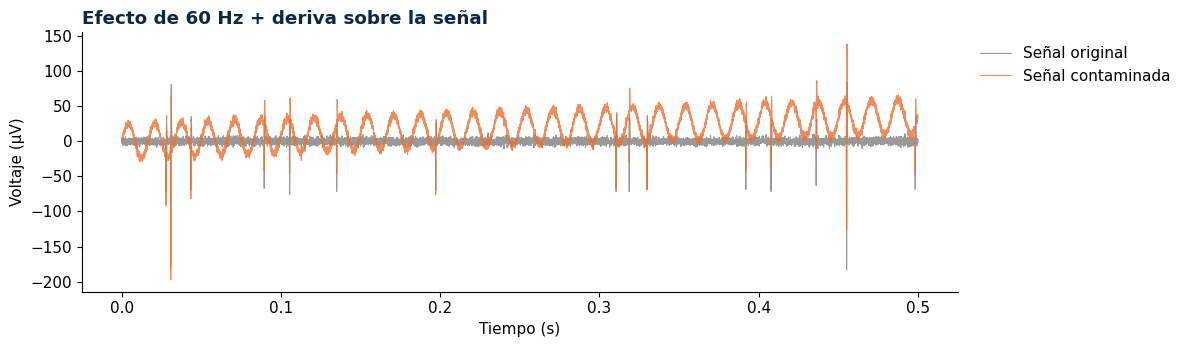

In [37]:
# =====================================================================
# Contaminar la señal con ruido de 60 Hz + deriva lenta, y ver el efecto
# =====================================================================

rng2 = np.random.default_rng(42)                    # semilla fija, aparte de la de la señal original

# --- 1. Interferencia de 60 Hz (ruido de línea eléctrica) --------------
amp_60hz = 25.0                                      # µV: notoria, del orden de un spike chico de B (70 µV), no absurda
interferencia = amp_60hz * np.sin(2*np.pi*60*t)      # senoidal pura de 60 Hz, en fase con t=0

# --- 2. Deriva lenta de la línea base (drift) ---------------------------
amp_deriva = 50.0                                    # µV: cuánto se desplaza la línea base en todo el registro
# medio ciclo de seno a lo largo de TODO el registro -> sube y luego baja suavemente
deriva = amp_deriva * np.sin(np.pi * t / t[-1])

# --- 3. Señal contaminada -------------------------------------------------
senal_ruidosa = senal + interferencia + deriva       # se suman, igual que se sumaron los spikes sobre el ruido

# =====================================================================
# Comparación visual: original vs. contaminada, en la misma ventana
# =====================================================================
t0, t1 = 0.0, 0.5                                    # ventana de 0.5 s para ver el efecto con claridad
m = (t >= t0) & (t < t1)

plt.figure(figsize=(12, 3.6))
plt.plot(t[m], senal[m], color="0.6", lw=0.8, label="Señal original")
plt.plot(t[m], senal_ruidosa[m], color=ORANGE, lw=0.8, alpha=0.8, label="Señal contaminada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (µV)")
plt.title("Efecto de 60 Hz + deriva sobre la señal", color=NAVY, fontweight="bold", loc="left")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()

# =====================================================================
# Recalcular el umbral sobre la señal contaminada, mismo método de antes
# =====================================================================
ventana_ruidosa = senal_ruidosa[t < 0.020]           # misma línea base: primeros 20 ms, sin spikes
ruido_ruidosa = np.abs(ventana_ruidosa).max()        # pico más extremo del "ruido" en esa ventana
umbral_ruidosa = -k * ruido_ruidosa                  # mismo k que ya tenían definido

print(f"umbral original     = {umbral:.1f} µV")
print(f"umbral con ruido    = {umbral_ruidosa:.1f} µV")
print(f"diferencia          = {umbral_ruidosa - umbral:.1f} µV")

# =====================================================================
# Detección sobre la señal contaminada, y comparación de conteos
# =====================================================================
indices = detectar(senal, umbral, muerto_ms=2.0, fs=FS)                    # ya la tenían, la repito para comparar
indices_ruidosa = detectar(senal_ruidosa, umbral_ruidosa, muerto_ms=2.0, fs=FS)

print(f"\nspikes detectados, señal limpia:      {len(indices)}")
print(f"spikes detectados, señal contaminada: {len(indices_ruidosa)}")

---
## Antes de subir a GitHub

- [ ] El notebook corre **de arriba abajo sin errores** (Entorno de ejecución → Reiniciar y ejecutar todo).
- [ ] No queda ningún `____` sin llenar.
- [ ] Todas las verificaciones dicen `OK`.
- [ ] Las cuatro preguntas están respondidas **con tus palabras**.
- [ ] Los tres prompts que escribiste tú están en el notebook.
- [ ] El archivo se llama `Practica_S3_ApellidoUno_ApellidoDos.ipynb`.

⚠️ Recuerda: **nunca pegues código que no puedas explicar en voz alta.**